<a href="https://colab.research.google.com/github/Shinyhunter95/Masters-Project/blob/main/AR(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

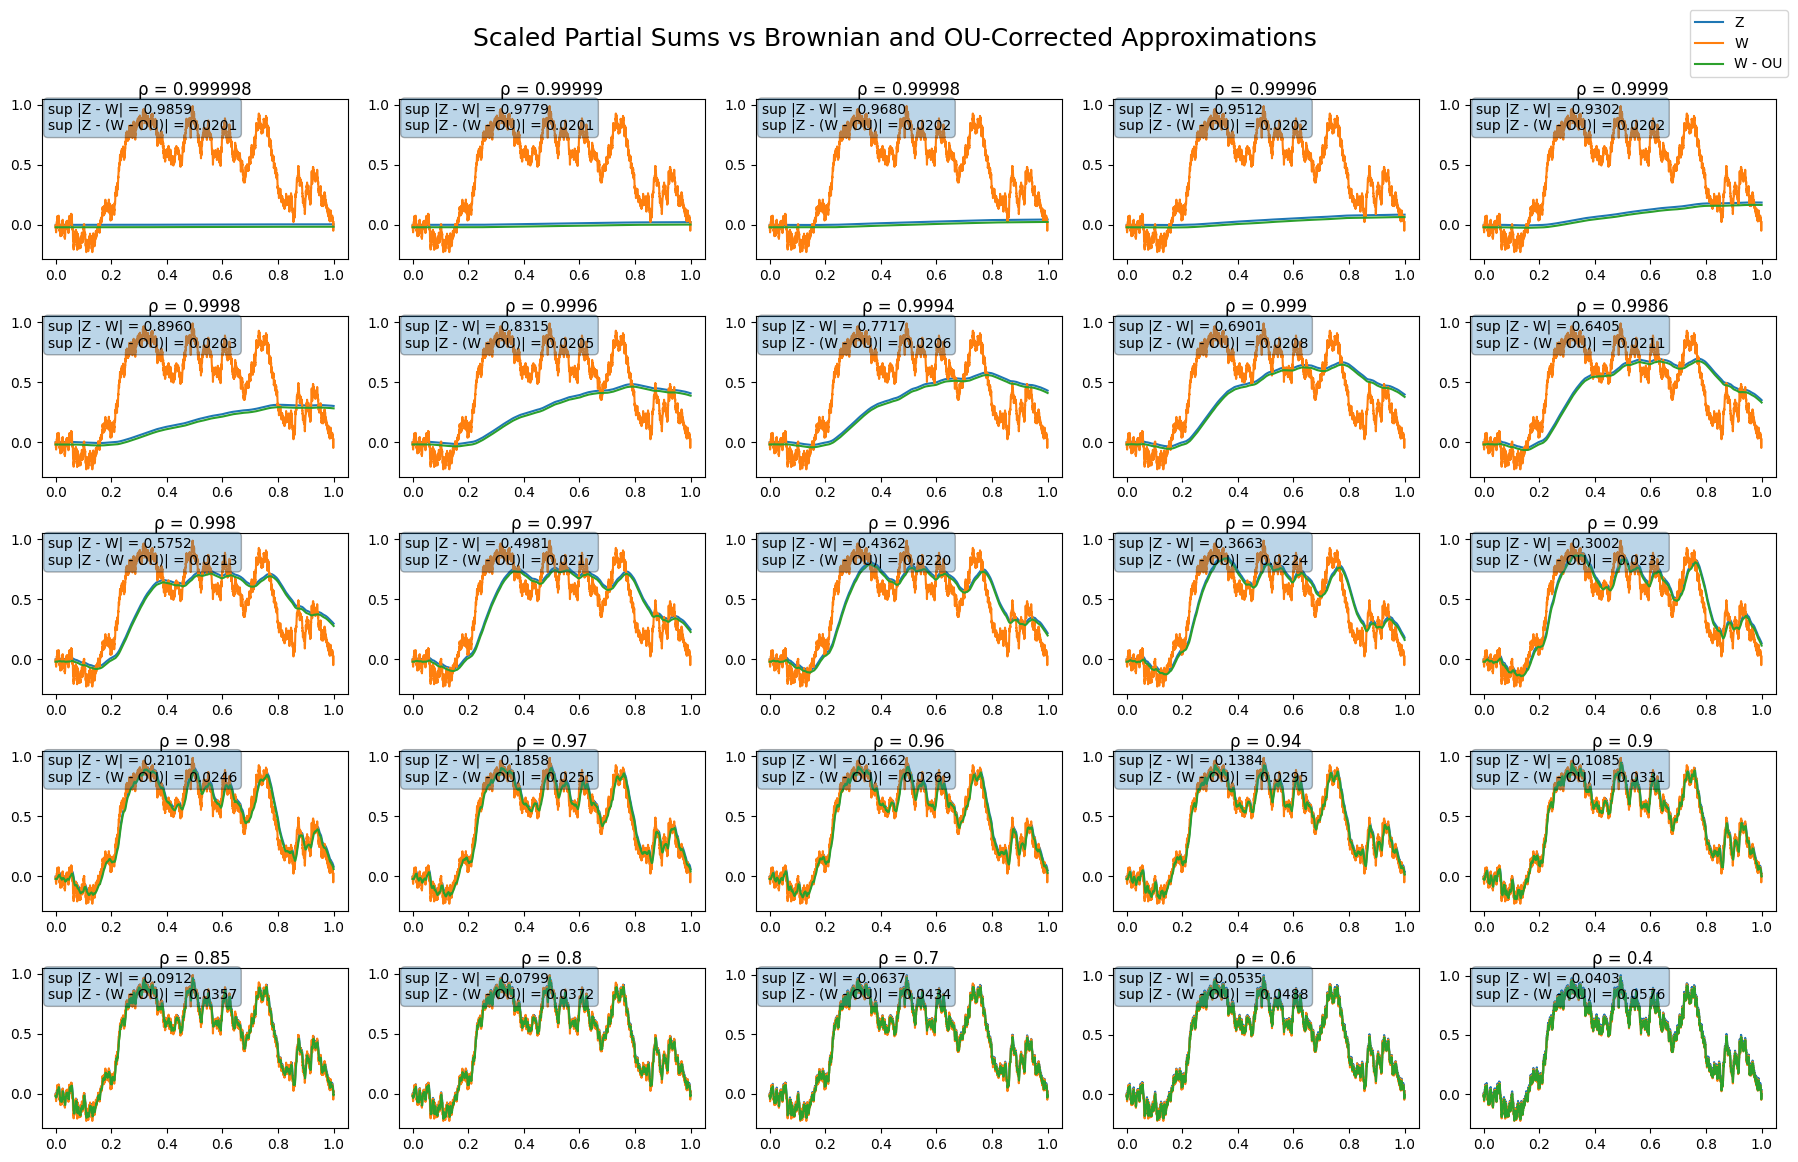

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------
# Parameters
# ---------------------------------

N = 5000
t = np.arange(N) / N
dt = 1 / N

# ---------------------------------
# Random Seed Normal
# ---------------------------------

rng = np.random.default_rng(12345)
eps = rng.standard_normal(N)

# ---------------------------------
# Figure Setup
# ---------------------------------

fig, axes = plt.subplots(5, 5, figsize=(18, 12))
axes = axes.flatten()

# ---------------------------------
# Loop Over a Values
# ---------------------------------

a_values = [0.01, 0.05, 0.1, 0.20, .5, 1, 2, 3, 5, 7, 10, 15, 20, 30, 50, 100, 150, 200, 300, 500, 750, 1000, 1500, 2000, 3000] #missing 4999

for idx, a in enumerate(a_values):

    rho = 1 - a / N
    c = N * np.log(1 / rho)

    # ---------------------------------
    # AR(1) Process
    # ---------------------------------

    U = np.zeros(N)

    for k in range(1, N):
        U[k] = rho * U[k-1] + eps[k]

    # ---------------------------------
    # Partial Sums
    # ---------------------------------

    S = np.cumsum(U)
    Z = (1 - rho) * S / np.sqrt(N)

    # ---------------------------------
    # Brownian Motion
    # ---------------------------------

    dW = eps / np.sqrt(N)
    W = np.cumsum(dW)

    # ---------------------------------
    # OU Correction
    # ---------------------------------

    alpha = np.exp(-c * dt)
    OU_term = np.zeros(N)

    for k in range(1, N):
        OU_term[k] = alpha * OU_term[k-1] + dW[k]

    W_corr = W - OU_term

    # ---------------------------------
    # Errors
    # ---------------------------------

    err_BM = np.max(np.abs(Z - W))
    err_corr = np.max(np.abs(Z - W_corr))

    # ---------------------------------
    # Plot
    # ---------------------------------

    ax = axes[idx]

    fig.suptitle(
        'Scaled Partial Sums vs Brownian and OU-Corrected Approximations',
        fontsize=18, y=.95)

    ax.plot(t, Z, label='Z')
    ax.plot(t, W, label='W')
    ax.plot(t, W_corr, label='W - OU')

    ax.set_title(f'\u03C1 = {rho}', pad=1)

    ax.text(
        0.02,
        0.98,
        (
            f'sup |Z - W| = {err_BM:.4f}\n'
            f'sup |Z - (W - OU)| = {err_corr:.4f}'
       ),
       transform=ax.transAxes,
       verticalalignment='top',
       bbox=dict(boxstyle='round', alpha=0.3)
    )

# ---------------------------------
# Shared Legend
# ---------------------------------

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', ncol=1, bbox_to_anchor=(1, 0.97))

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

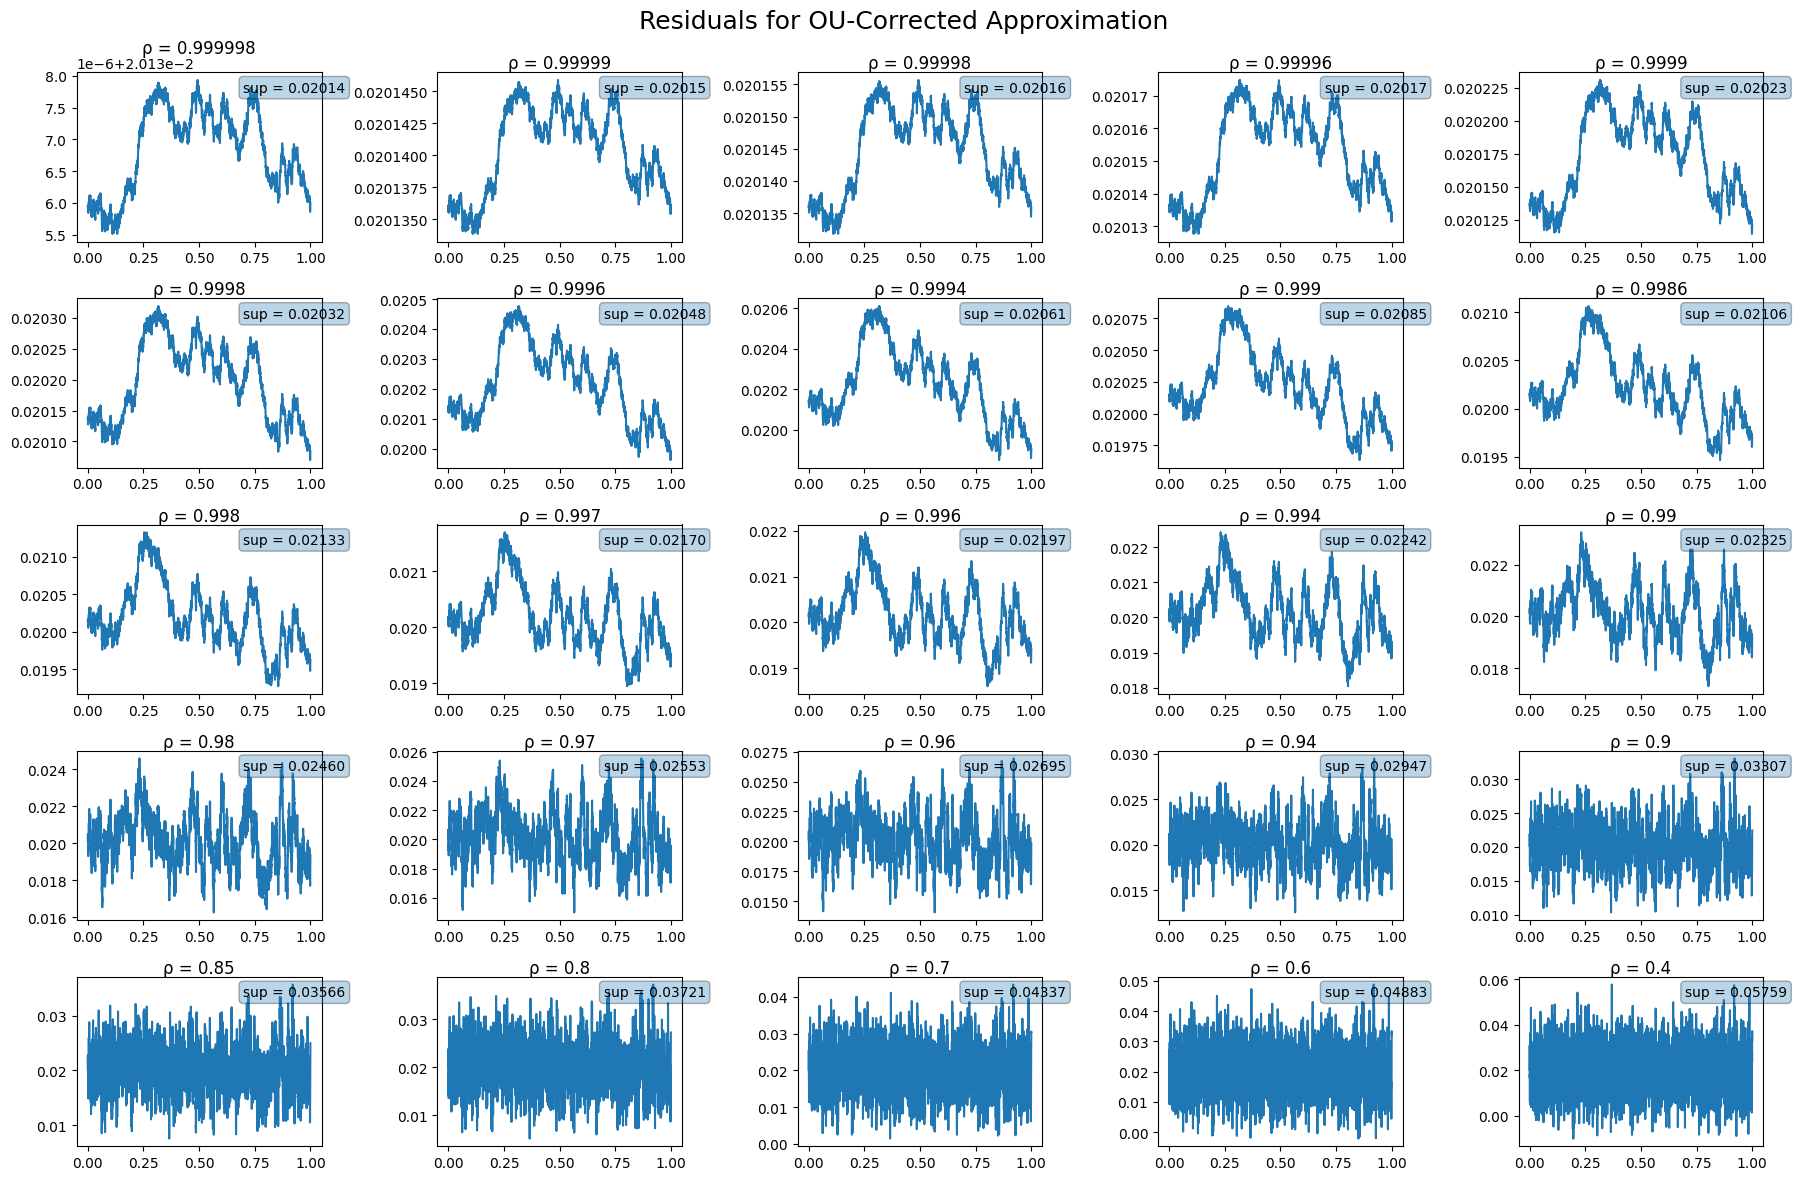

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------
# Parameters
# ---------------------------------

N = 5000
dt = 1 / N
t = np.linspace(0, 1, N)

# ---------------------------------
# Random Seed Normal
# ---------------------------------

rng = np.random.default_rng(12345)
eps = rng.standard_normal(N)

# ---------------------------------
# Figure Setup
# ---------------------------------

fig, axes = plt.subplots(5, 5, figsize=(18, 12))
axes = axes.flatten()

# ---------------------------------
# Loop Over a values
# ---------------------------------

a_values = [0.01, 0.05, 0.1, 0.20, .5, 1, 2, 3, 5, 7, 10, 15, 20, 30, 50, 100, 150, 200, 300, 500, 750, 1000, 1500, 2000, 3000] #missing 4999

for idx, a in enumerate(a_values):

    rho = 1 - a / N
    c = N * np.log(1 / rho)

    # ---------------------------------
    # AR(1) Process
    # ---------------------------------

    U = np.zeros(N)

    for k in range(1, N):
        U[k] = rho * U[k-1] + eps[k]

    # ---------------------------------
    # Partial Sums
    # ---------------------------------

    S = np.cumsum(U)
    Z = (1 - rho) * S / np.sqrt(N)

    # ---------------------------------
    # Brownian Motion
    # ---------------------------------

    dW = eps / np.sqrt(N)
    W = np.cumsum(dW)

    # ---------------------------------
    # OU Correction
    # ---------------------------------

    alpha = np.exp(-c * dt)
    OU_term = np.zeros(N)

    for k in range(1, N):
        OU_term[k] = alpha * OU_term[k-1] + dW[k]

    W_corr = W - OU_term

    # ---------------------------------
    # Residual
    # ---------------------------------

    residual = Z - W_corr
    sup_residual = np.max(np.abs(residual))

    # ---------------------------------
    # Plot
    # ---------------------------------

    ax = axes[idx]

    fig.suptitle(
    'Residuals for OU-Corrected Approximation',
    fontsize=18
    )
    ax.plot(t, residual)

    # Put text inside the plot
    ax.text(
        0.68,                # x-position in axes coords
        0.95,                # y-position in axes coords
        f'sup = {sup_residual:.5f}',
        transform=ax.transAxes,
        verticalalignment='top',
        bbox=dict(boxstyle='round', alpha=0.3)
    )

    ax.set_title(f'\u03C1 = {rho}', pad=1)

# ---------------------------------
# Layout
# ---------------------------------

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------
# Parameters
# ---------------------------------

N = 5000
t = np.arange(N) / N
dt = 1 / N

# ---------------------------------
# Random Seed Normal
# ---------------------------------

rng = np.random.default_rng(12345)
eps = rng.standard_normal(N)

# ---------------------------------
# Table
# ---------------------------------

print(
    f"{'\u03C1':>10} "
    f"{'c':>8} "
    f"{'sup|Z-W|':>15} "
    f"{'sup|Z-(W-OU)|':>18} "
    f"{'sup|OU|':>15} "
    f"{'Error Reduction':>20}"
)

a_values = [0.01, 0.05, 0.1, 0.20, .5, 1, 2, 3, 5, 7, 10, 15, 20, 30, 50, 100, 150, 200, 300, 500, 750, 1000, 1500, 2000, 3000, 4999]

for a in a_values:

    rho = 1 - a / N
    c = N * np.log(1 / rho)

    # ---------------------------------
    # AR(1) Process
    # ---------------------------------

    U = np.zeros(N)

    for k in range(1, N):
        U[k] = rho * U[k-1] + eps[k]

    # ---------------------------------
    # Partial Sums
    # ---------------------------------

    S = np.cumsum(U)
    Z = (1 - rho) * S / np.sqrt(N)

    # ---------------------------------
    # Brownian Motion
    # ---------------------------------

    dW = eps / np.sqrt(N)
    W = np.cumsum(dW)

    # ---------------------------------
    # OU Correction
    # ---------------------------------

    alpha = np.exp(-c * dt)
    OU_term = np.zeros(N)

    for k in range(1, N):
        OU_term[k] = alpha * OU_term[k-1] + dW[k]

    W_corr = W - OU_term

    # ---------------------------------
    # Errors
    # ---------------------------------

    err_BM = np.max(np.abs(Z - W))
    err_corr = np.max(np.abs(Z - W_corr))
    sup_OU = np.max(np.abs(OU_term))

    # ---------------------------------
    # Error Reduction Percentage
    # ---------------------------------

    error_reduction = 100 * (1 - err_corr / err_BM)

    # ---------------------------------
    # Print Table
    # ---------------------------------

    print(
        f"{rho:10.6f} "
        f"{c:8.2f} "
        f"{err_BM:15.6f} "
        f"{err_corr:18.6f} "
        f"{sup_OU:15.6f} "
        f"{error_reduction:19.2f}%"
    )

         ρ        c        sup|Z-W|      sup|Z-(W-OU)|         sup|OU|      Error Reduction
  0.999998     0.01        0.985917           0.020138        1.006055               97.96%
  0.999990     0.05        0.977898           0.020146        0.998044               97.94%
  0.999980     0.10        0.967994           0.020156        0.988150               97.92%
  0.999960     0.20        0.951203           0.020175        0.971378               97.88%
  0.999900     0.50        0.930152           0.020231        0.950383               97.82%
  0.999800     1.00        0.896041           0.020319        0.916360               97.73%
  0.999600     2.00        0.831467           0.020477        0.851944               97.54%
  0.999400     3.00        0.771687           0.020611        0.792298               97.33%
  0.999000     5.00        0.690056           0.020847        0.710903               96.98%
  0.998600     7.00        0.640476           0.021062        0.661538          

In [ ]:
import numpy as np

# ---------------------------------
# Parameters
# ---------------------------------

N = 5000
dt = 1 / N
M = 5000              # Monte Carlo Replications
B = 5000              # Bootstrap Resamples

a_values = [0.01, 0.05, 0.1, 0.20, .5, 1, 2, 3, 5, 7, 10, 15, 20, 30, 50, 100, 150,
            200, 300, 500, 750, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4250, 4500,
            4700, 4800, 4850, 4900, 4950, 4970, 4980, 4985, 4990, 4993, 4995, 4997,
            4998, 4999, 4999.5, 4999.8, 4999.9, 4999.95, 4999.99]

rng = np.random.default_rng(12345)

# ---------------------------------
# Storage
# ---------------------------------

print(
    f"{'\u03C1':>10} "
    f"{'c':>8} "
    f"{'Mean D':>12} "
    f"{'SE D':>10} "
    f"{'Mean R':>11} "
    f"{'SE R':>11} "
    f"{'t-stat':>10} "
    f"{'CI D low':>12} "
    f"{'CI D high':>12} "
    f"{'reject H0':>12} "
)

# ---------------------------------
# Main Loop
# ---------------------------------

for a in a_values:

    rho = 1 - a / N
    c = N * np.log(1 / rho)
    alpha = np.exp(-c * dt)

    D = np.zeros(M)
    R = np.zeros(M)

    # ---------------------------------
    # Monte Carlo Loop
    # ---------------------------------

    for i in range(M):

        eps = rng.standard_normal(N)

        # ---------------------------------
        # AR(1)
        # ---------------------------------
        U = np.zeros(N)
        for k in range(1, N):
            U[k] = rho * U[k-1] + eps[k]

        S = np.cumsum(U)
        Z = (1 - rho) * S / np.sqrt(N)

        # ---------------------------------
        # Brownian Motion
        # ---------------------------------
        dW = eps / np.sqrt(N)
        W = np.cumsum(dW)

        # ---------------------------------
        # OU Correction
        # ---------------------------------
        OU = np.zeros(N)
        for k in range(1, N):
            OU[k] = alpha * OU[k-1] + dW[k]

        W_corr = W - OU

        # ---------------------------------
        # Sup Norm Errors
        # ---------------------------------
        err_BM = np.max(np.abs(Z - W))
        err_corr = np.max(np.abs(Z - W_corr))

        D[i] = err_BM - err_corr

        R[i] = 100 * (err_BM - err_corr) / err_BM

    # ---------------------------------
    # Statistics
    # ---------------------------------

    mean_D = np.mean(D)
    se_D = np.std(D, ddof=1) / np.sqrt(M)
    t_stat = mean_D / se_D
    mean_R = np.mean(R)
    se_R = np.std(R, ddof=1) / np.sqrt(M)

    # ---------------------------------
    # Bootstrap CI
    # ---------------------------------

    boot_means = np.empty(B)

    for b in range(B):
        sample = rng.choice(D, size=M, replace=True)
        boot_means[b] = np.mean(sample)

    ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])

    # ---------------------------------
    # Decision Rule (One-Sided t Test)
    # ---------------------------------

    reject = t_stat > 1.645 #Z_alpha at .95

    print(
        f"{rho:10.6f} "
        f"{c:8.2f} "
        f"{mean_D:12.6f} "
        f"{se_D:10.6f} "
        f"{mean_R:10.3f}% "
        f"{se_R:10.3f}% "
        f"{t_stat:10.3f} "
        f"{ci_low:12.6f} "
        f"{ci_high:12.6f} "
        f"{str(reject):>12}"
    )

         ρ        c       Mean D       SE D      Mean R        SE R     t-stat     CI D low    CI D high    reject H0 
  0.999998     0.01     1.224666   0.007060     98.929%      0.014%    173.477     1.210776     1.238529         True
  0.999990     0.05     1.236810   0.007254     98.948%      0.014%    170.507     1.223037     1.250903         True
  0.999980     0.10     1.211905   0.006946     98.917%      0.014%    174.486     1.197889     1.225672         True
  0.999960     0.20     1.177140   0.006644     98.907%      0.014%    177.185     1.163957     1.189704         True
  0.999900     0.50     1.114222   0.005948     98.864%      0.014%    187.330     1.102759     1.125775         True
  0.999800     1.00     1.017909   0.004843     98.774%      0.015%    210.170     1.008125     1.027393         True
  0.999600     2.00     0.889497   0.003711     98.632%      0.016%    239.675     0.882479     0.896783         True
  0.999400     3.00     0.810308   0.003059     98.495%

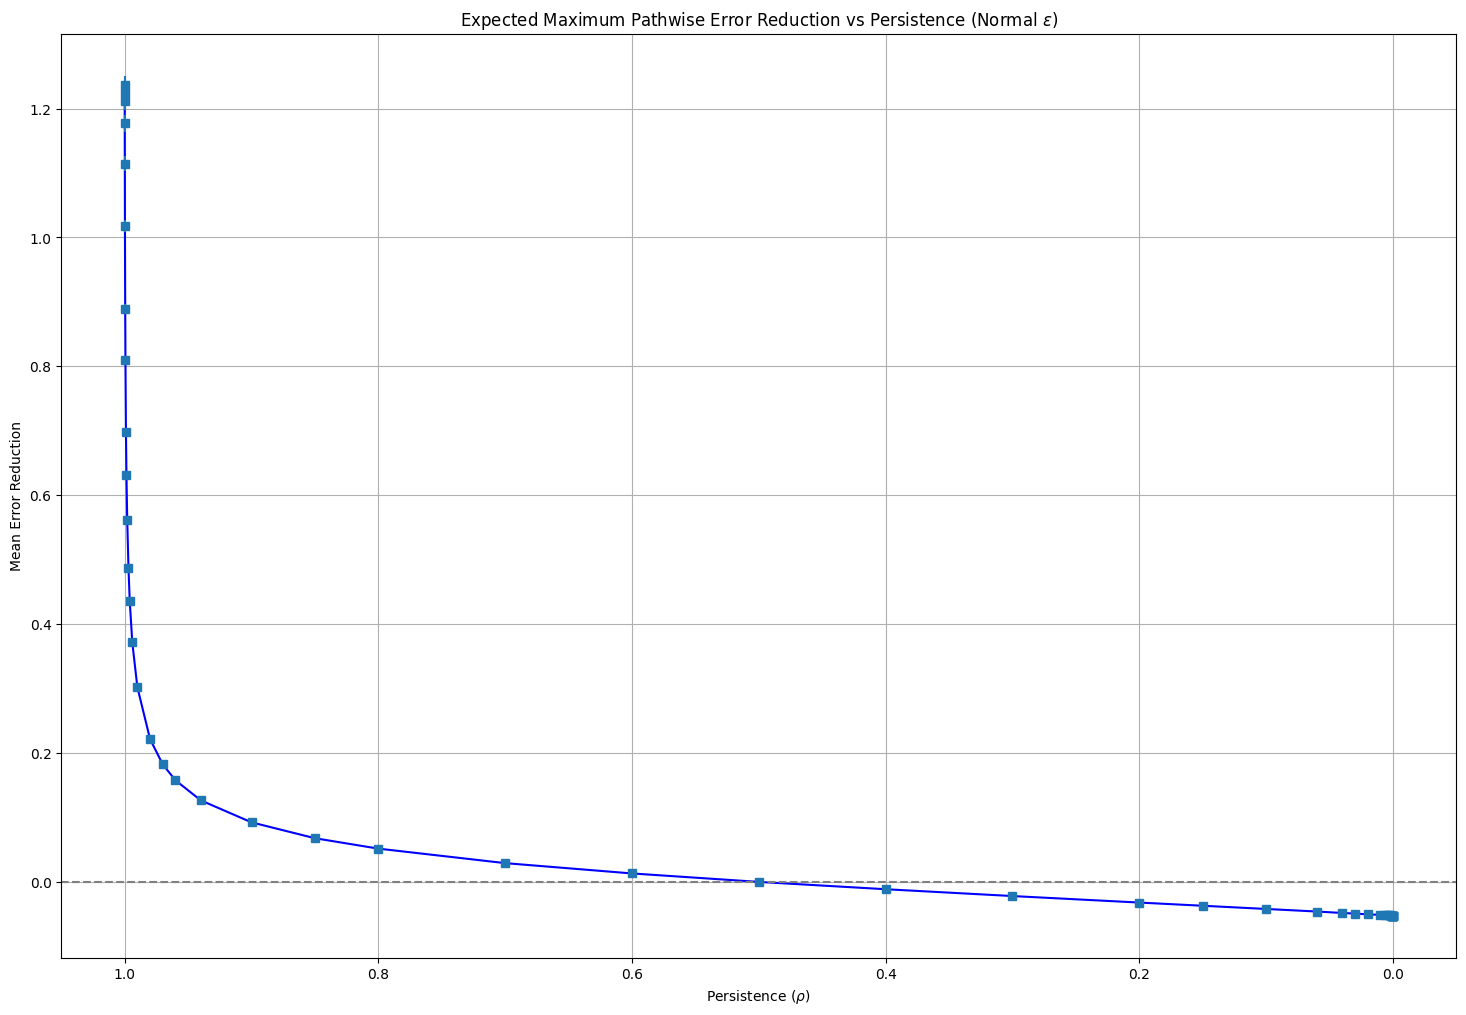

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------
# Parameters
# ---------------------------------

data = [
    [0.999998, 0.01, 1.224666, 0.007060, 98.929, 0.014, 1.210776, 1.238529],
    [0.999990, 0.05, 1.236810, 0.007254, 98.948, 0.014, 1.223037, 1.250903],
    [0.999980, 0.10, 1.211905, 0.006946, 98.917, 0.014, 1.197889, 1.225672],
    [0.999960, 0.20, 1.177140, 0.006644, 98.907, 0.014, 1.163957, 1.189704],
    [0.999900, 0.50, 1.114222, 0.005948, 98.864, 0.014, 1.102759, 1.125775],
    [0.999800, 1.00, 1.017909, 0.004843, 98.774, 0.015, 1.008125, 1.027393],
    [0.999600, 2.00, 0.889497, 0.003711, 98.632, 0.016, 0.882479, 0.896783],
    [0.999400, 3.00, 0.810308, 0.003059, 98.495, 0.017, 0.804519, 0.816270],
    [0.999000, 5.00, 0.697315, 0.002329, 98.263, 0.019, 0.692697, 0.701882],
    [0.998600, 7.00, 0.630722, 0.001939, 98.068, 0.021, 0.626953, 0.634503],
    [0.998000, 10.01, 0.561854, 0.001590, 97.788, 0.023, 0.558672, 0.564933],
    [0.997000, 15.02, 0.486635, 0.001227, 97.407, 0.026, 0.484179, 0.488929],
    [0.996000, 20.04, 0.435356, 0.001049, 97.074, 0.028, 0.433272, 0.437422],
    [0.994000, 30.09, 0.371450, 0.000794, 96.449, 0.033, 0.369876, 0.372985],
    [0.990000, 50.25, 0.302040, 0.000593, 95.466, 0.039, 0.300940, 0.303213],
    [0.980000, 101.01, 0.221651, 0.000391, 93.277, 0.051, 0.220901, 0.222434],
    [0.970000, 152.30, 0.182318, 0.000306, 91.495, 0.057, 0.181707, 0.182902],
    [0.960000, 204.11, 0.157732, 0.000253, 89.832, 0.064, 0.157234, 0.158219],
    [0.940000, 309.38, 0.126503, 0.000200, 86.702, 0.074, 0.126109, 0.126890],
    [0.900000, 526.80, 0.092387, 0.000141, 80.572, 0.086, 0.092110, 0.092660],
    [0.850000, 812.59, 0.067751, 0.000107, 72.894, 0.097, 0.067543, 0.067963],
    [0.800000, 1115.72, 0.051601, 0.000089, 65.116, 0.104, 0.051429, 0.051780],
    [0.700000, 1783.37, 0.029100, 0.000066, 47.524, 0.108, 0.028969, 0.029231],
    [0.600000, 2554.13, 0.013101, 0.000056, 26.417, 0.106, 0.012993, 0.013209],
    [0.500000, 3465.74, -0.000029, 0.000049, -0.455, 0.119, -0.000124, 0.000065],
    [0.400000, 4581.45, -0.011382, 0.000047, -35.928, 0.199, -0.011474, -0.011291],
    [0.300000, 6019.86, -0.021975, 0.000048, -87.132, 0.411, -0.022069, -0.021878],
    [0.200000, 8047.19, -0.032079, 0.000053, -169.893, 0.936, -0.032182, -0.031975],
    [0.150000, 9485.60, -0.037037, 0.000054, -233.480, 1.472, -0.037145, -0.036929],
    [0.100000, 11512.93, -0.042002, 0.000056, -332.281, 2.544, -0.042111, -0.041893],
    [0.060000, 14067.05, -0.045988, 0.000059, -470.299, 4.532, -0.046099, -0.045872],
    [0.040000, 16094.38, -0.048236, 0.000062, -573.742, 6.558, -0.048355, -0.048119],
    [0.030000, 17532.79, -0.049214, 0.000061, -683.693, 8.751, -0.049334, -0.049091],
    [0.020000, 19560.12, -0.050288, 0.000062, -791.260, 11.976, -0.050408, -0.050161],
    [0.010000, 23025.85, -0.051263, 0.000062, -998.099, 19.717, -0.051383, -0.051137],
    [0.006000, 25579.98, -0.051667, 0.000063, -1181.023, 29.133, -0.051793, -0.051544],
    [0.004000, 27607.30, -0.051864, 0.000063, -1212.136, 31.651, -0.051987, -0.051744],
    [0.003000, 29045.71, -0.051908, 0.000063, -1353.944, 41.838, -0.052032, -0.051792],
    [0.002000, 31073.04, -0.052084, 0.000063, -1539.186, 53.732, -0.052211, -0.051959],
    [0.001400, 32856.42, -0.052218, 0.000064, -1539.103, 58.081, -0.052347, -0.052092],
    [0.001000, 34538.78, -0.052234, 0.000064, -1709.938, 84.157, -0.052359, -0.052108],
    [0.000600, 37092.90, -0.052183, 0.000061, -1826.849, 97.460, -0.052300, -0.052063],
    [0.000400, 39120.23, -0.052378, 0.000063, -1873.152, 108.171, -0.052504, -0.052257],
    [0.000200, 42585.97, -0.052225, 0.000062, -1937.724, 129.151, -0.052345, -0.052100],
    [0.000100, 46051.70, -0.052240, 0.000061, -2161.994, 224.831, -0.052363, -0.052122],
    [0.000040, 50633.16, -0.052235, 0.000064, -2068.782, 153.845, -0.052358, -0.052111],
    [0.000020, 54098.89, -0.052232, 0.000062, -2703.612, 417.298, -0.052351, -0.052112],
    [0.000010, 57564.63, -0.052339, 0.000063, -3131.351, 410.329, -0.052465, -0.052215],
    [0.000002, 65611.82, -0.052281, 0.000063, -3702.137, 1247.629, -0.052405, -0.052158],
]

arr = np.array(data)

rho = arr[:,0]
mean_D = arr[:,2]
se_D = arr[:,3]
ci_low = arr[:,6]
ci_high = arr[:,7]

yerr = np.vstack([
    mean_D - ci_low,
    ci_high - mean_D
])

# ---------------------------------
# Plot
# ---------------------------------

plt.figure(figsize=(18, 12))
plt.plot(rho, mean_D, color ='blue')
plt.axhline(0, linestyle='--', color='gray', linewidth=1.5)
plt.xlabel(r'Persistence $(\rho)$')
plt.ylabel('Mean Error Reduction')
plt.title('Expected Maximum Pathwise Error Reduction vs Persistence (Normal $\u03B5$)')
plt.errorbar(rho, mean_D, yerr=yerr, fmt='s')
plt.gca().invert_xaxis()
plt.grid(True)


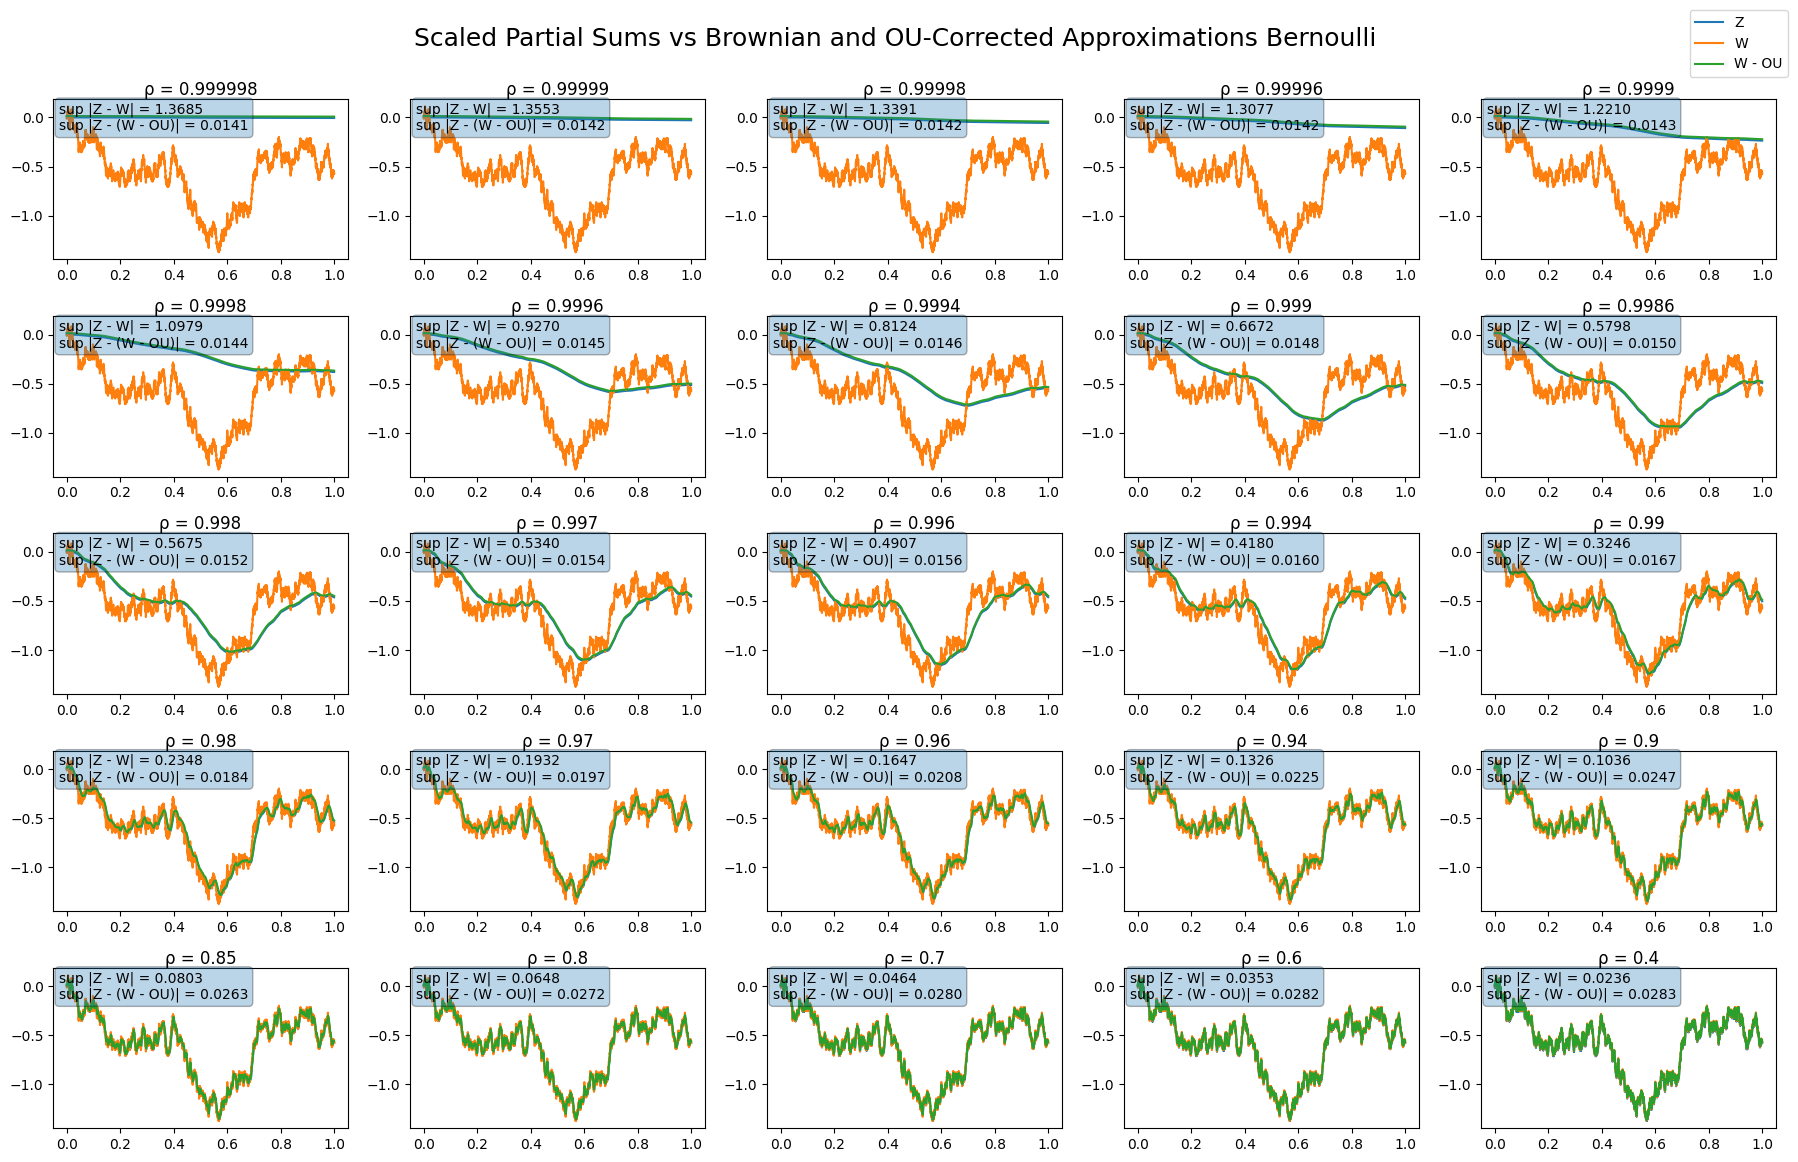

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------
# Parameters
# ---------------------------------

N = 5000
t = np.arange(N) / N
dt = 1 / N

# ---------------------------------
# Random Seed Bernoulli
# ---------------------------------

rng = np.random.default_rng(12345)
eps = rng.choice([-1, 1], size=N)

# ---------------------------------
# Figure Setup
# ---------------------------------

fig, axes = plt.subplots(5, 5, figsize=(18, 12))
axes = axes.flatten()

# ---------------------------------
# Loop Over a Values
# ---------------------------------

a_values = [0.01, 0.05, 0.1, 0.20, .5, 1, 2, 3, 5, 7, 10, 15, 20, 30, 50, 100, 150, 200, 300, 500, 750, 1000, 1500, 2000, 3000] #missing 4999


for idx, a in enumerate(a_values):

    rho = 1 - a / N
    c = N * np.log(1 / rho)

    # ---------------------------------
    # AR(1) Process
    # ---------------------------------

    U = np.zeros(N)

    for k in range(1, N):
        U[k] = rho * U[k-1] + eps[k]

    # ---------------------------------
    # Partial Sums
    # ---------------------------------

    S = np.cumsum(U)
    Z = (1 - rho) * S / np.sqrt(N)

    # ---------------------------------
    # Brownian Motion
    # ---------------------------------

    dW = eps / np.sqrt(N)
    W = np.cumsum(dW)

    # ---------------------------------
    # OU Correction
    # ---------------------------------

    alpha = np.exp(-c * dt)
    OU_term = np.zeros(N)

    for k in range(1, N):
        OU_term[k] = alpha * OU_term[k-1] + dW[k]

    W_corr = W - OU_term

    # ---------------------------------
    # Errors
    # ---------------------------------

    err_BM = np.max(np.abs(Z - W))
    err_corr = np.max(np.abs(Z - W_corr))

    # ---------------------------------
    # Plot
    # ---------------------------------

    ax = axes[idx]
    fig.suptitle(
        'Scaled Partial Sums vs Brownian and OU-Corrected Approximations Bernoulli',
        fontsize=18, y=.95)

    ax.plot(t, Z, label='Z')
    ax.plot(t, W, label='W')
    ax.plot(t, W_corr, label='W - OU')

    ax.set_title(f'\u03C1 = {rho}', pad=1)

    ax.text(
        0.02,
        0.98,
        (
            f'sup |Z - W| = {err_BM:.4f}\n'
            f'sup |Z - (W - OU)| = {err_corr:.4f}'
       ),
       transform=ax.transAxes,
       verticalalignment='top',
       bbox=dict(boxstyle='round', alpha=0.3)
    )

# ---------------------------------
# Shared legend
# ---------------------------------

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', ncol=1, bbox_to_anchor=(1, 0.97))

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

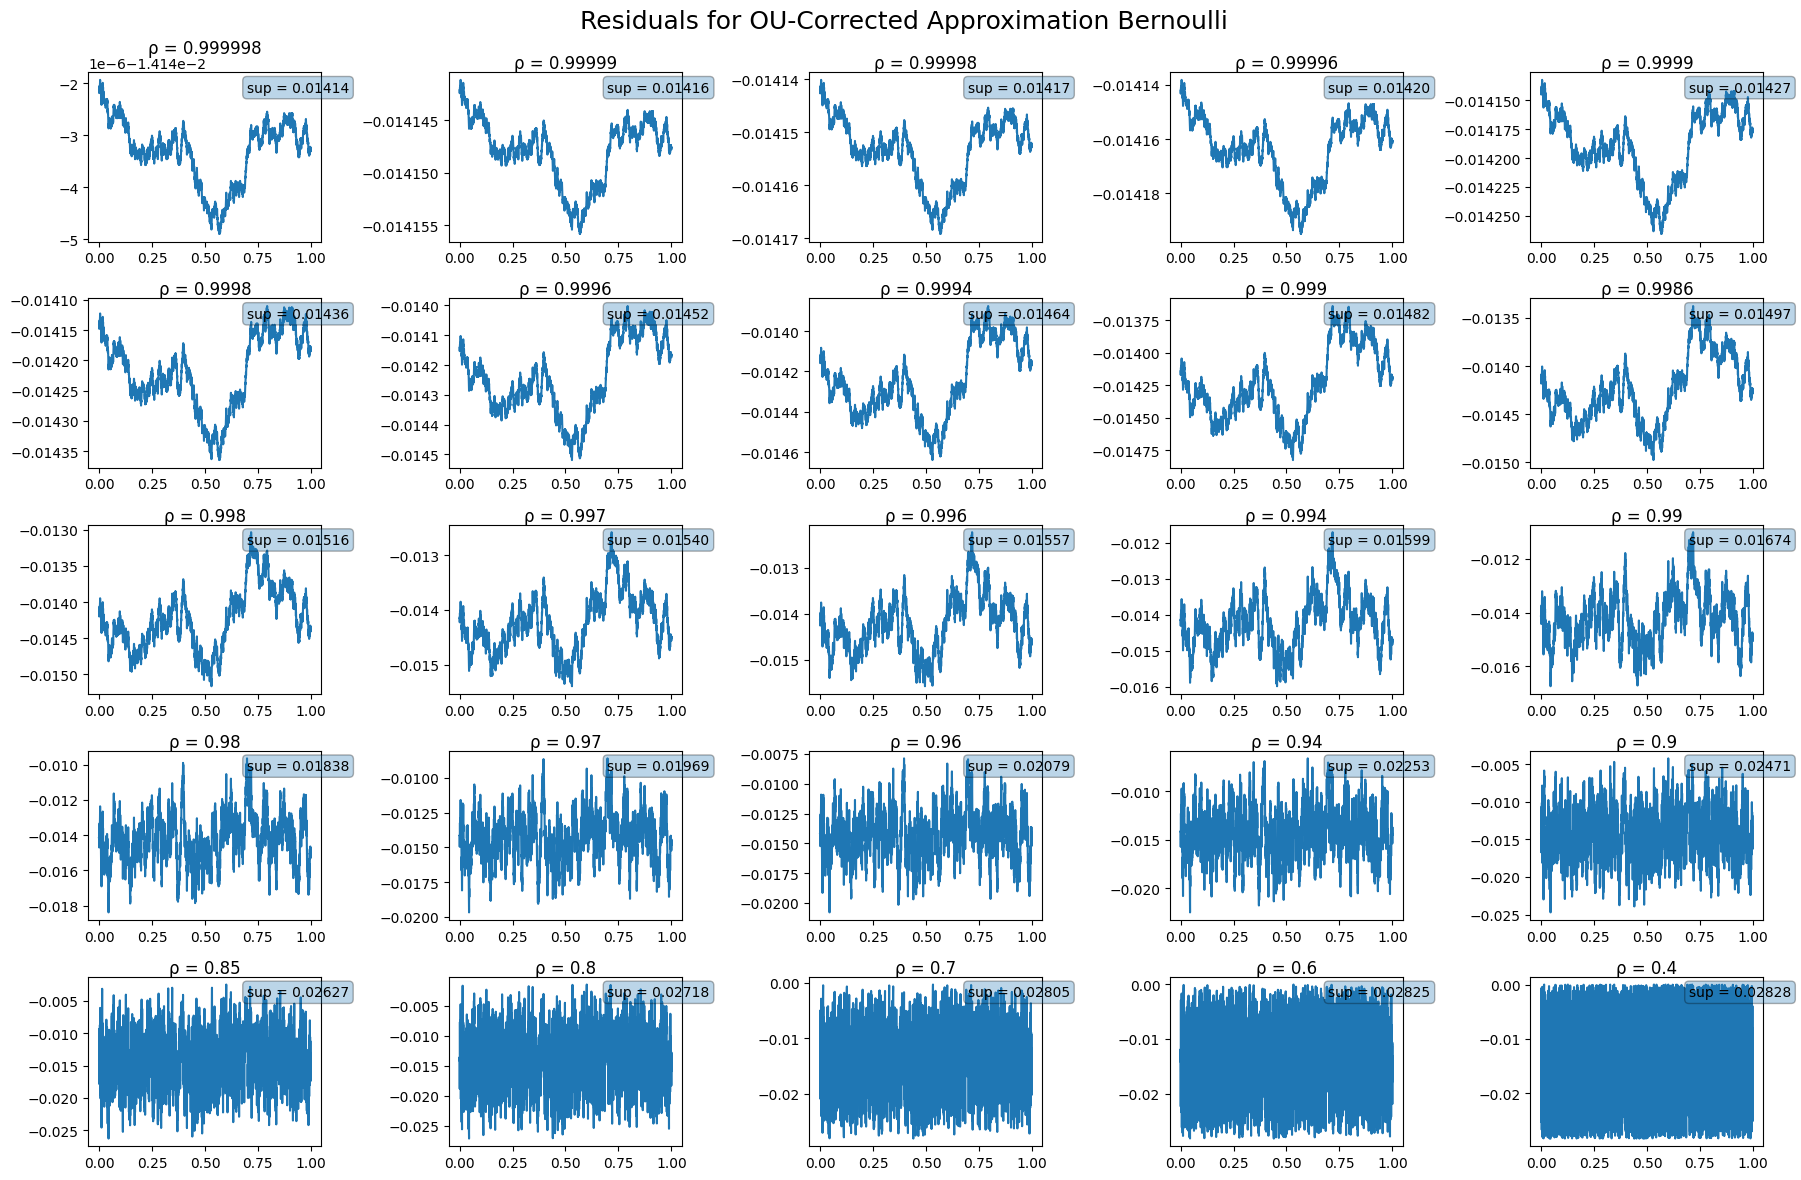

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------
# Parameters
# ---------------------------------

N = 5000
dt = 1 / N
t = np.linspace(0, 1, N)

# ---------------------------------
# Random Seed Bernoulli
# ---------------------------------

rng = np.random.default_rng(12345)
eps = rng.choice([-1, 1], size=N)

# ---------------------------------
# Figure Setup
# ---------------------------------

fig, axes = plt.subplots(5, 5, figsize=(18, 12))
axes = axes.flatten()

# ---------------------------------
# Loop Over a values
# ---------------------------------

a_values = [0.01, 0.05, 0.1, 0.20, .5, 1, 2, 3, 5, 7, 10, 15, 20, 30, 50, 100, 150, 200, 300, 500, 750, 1000, 1500, 2000, 3000] #missing 4999

for idx, a in enumerate(a_values):

    rho = 1 - a / N
    c = N * np.log(1 / rho)

    # ---------------------------------
    # AR(1) Process
    # ---------------------------------

    U = np.zeros(N)

    for k in range(1, N):
        U[k] = rho * U[k-1] + eps[k]

    # ---------------------------------
    # Partial Sums
    # ---------------------------------

    S = np.cumsum(U)
    Z = (1 - rho) * S / np.sqrt(N)

    # ---------------------------------
    # Brownian Motion
    # ---------------------------------

    dW = eps / np.sqrt(N)
    W = np.cumsum(dW)

    # ---------------------------------
    # OU Correction
    # ---------------------------------

    alpha = np.exp(-c * dt)
    OU_term = np.zeros(N)

    for k in range(1, N):
        OU_term[k] = alpha * OU_term[k-1] + dW[k]

    W_corr = W - OU_term

    # ---------------------------------
    # Residual
    # ---------------------------------

    residual = Z - W_corr
    sup_residual = np.max(np.abs(residual))

    # ---------------------------------
    # Plot
    # ---------------------------------

    ax = axes[idx]
    fig.suptitle(
    'Residuals for OU-Corrected Approximation Bernoulli',
    fontsize=18
    )
    ax.plot(t, residual)

    # Put text inside the plot
    ax.text(
        0.68,                # x-position in axes coords
        0.95,                # y-position in axes coords
        f'sup = {sup_residual:.5f}',
        transform=ax.transAxes,
        verticalalignment='top',
        bbox=dict(boxstyle='round', alpha=0.3)
    )

    ax.set_title(f'\u03C1 = {rho}', pad=1)

# ---------------------------------
# Layout
# ---------------------------------

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# ---------------------------------
# Parameters
# ---------------------------------

N = 5000
t = np.arange(N) / N
dt = 1 / N

# ---------------------------------
# Random Seed Bernoulli
# ---------------------------------

rng = np.random.default_rng(12345)
eps = rng.choice([-1, 1], size=N)

# ---------------------------------
# Table
# ---------------------------------

print(
    f"{'\u03C1':>10} "
    f"{'c':>8} "
    f"{'sup|Z-W|':>15} "
    f"{'sup|Z-(W-OU)|':>18} "
    f"{'sup|OU|':>15} "
    f"{'Error Reduction':>20}"
)

a_values = [0.01, 0.05, 0.1, 0.20, .5, 1, 2, 3, 5, 7, 10, 15, 20, 30, 50, 100, 150,
            200, 300, 500, 750, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4250, 4500,
            4700, 4800, 4850, 4900, 4950, 4970, 4980, 4985, 4990, 4993, 4995, 4997,
            4998, 4999, 4999.5, 4999.8, 4999.9, 4999.95, 4999.99]

for a in a_values:

    rho = 1 - a / N
    c = N * np.log(1 / rho)

    # ---------------------------------
    # AR(1) Process
    # ---------------------------------

    U = np.zeros(N)

    for k in range(1, N):
        U[k] = rho * U[k-1] + eps[k]

    # ---------------------------------
    # Partial Sums
    # ---------------------------------

    S = np.cumsum(U)
    Z = (1 - rho) * S / np.sqrt(N)

    # ---------------------------------
    # Brownian Motion
    # ---------------------------------

    dW = eps / np.sqrt(N)
    W = np.cumsum(dW)

    # ---------------------------------
    # OU Correction
    # ---------------------------------

    alpha = np.exp(-c * dt)
    OU_term = np.zeros(N)

    for k in range(1, N):
        OU_term[k] = alpha * OU_term[k-1] + dW[k]

    W_corr = W - OU_term

    # ---------------------------------
    # Errors
    # ---------------------------------

    err_BM = np.max(np.abs(Z - W))
    err_corr = np.max(np.abs(Z - W_corr))
    sup_OU = np.max(np.abs(OU_term))

    # ---------------------------------
    # Error Reduction Percentage
    # ---------------------------------

    error_reduction = 100 * (1 - err_corr / err_BM)

    # ---------------------------------
    # Print Table
    # ---------------------------------

    print(
        f"{rho:10.6f} "
        f"{c:8.2f} "
        f"{err_BM:15.6f} "
        f"{err_corr:18.6f} "
        f"{sup_OU:15.6f} "
        f"{error_reduction:19.2f}%"
    )

         ρ        c        sup|Z-W|      sup|Z-(W-OU)|         sup|OU|      Error Reduction
  0.999998     0.01        1.368457           0.014145        1.382602               98.97%
  0.999990     0.05        1.355277           0.014156        1.369432               98.96%
  0.999980     0.10        1.339105           0.014169        1.353274               98.94%
  0.999960     0.20        1.307749           0.014195        1.321944               98.91%
  0.999900     0.50        1.221039           0.014266        1.235304               98.83%
  0.999800     1.00        1.097856           0.014365        1.112220               98.69%
  0.999600     2.00        0.927019           0.014519        0.941537               98.43%
  0.999400     3.00        0.812365           0.014638        0.827004               98.20%
  0.999000     5.00        0.667173           0.014824        0.681997               97.78%
  0.998600     7.00        0.579834           0.014975        0.594809          

In [ ]:
import numpy as np

# ---------------------------------
# Parameters
# ---------------------------------

N = 5000
dt = 1 / N
M = 5000              # Monte Carlo Replications
B = 5000              # Bootstrap Resamples

a_values = [0.01, 0.05, 0.1, 0.20, .5, 1, 2, 3, 5, 7, 10, 15, 20, 30, 50, 100, 150,
            200, 300, 500, 750, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4250, 4500,
            4700, 4800, 4850, 4900, 4950, 4970, 4980, 4985, 4990, 4993, 4995, 4997,
            4998, 4999, 4999.5, 4999.8, 4999.9, 4999.95, 4999.99]

rng = np.random.default_rng(12345)

# ---------------------------------
# Storage
# ---------------------------------

print(
    f"{'\u03C1':>10} "
    f"{'c':>8} "
    f"{'Mean D':>12} "
    f"{'SE D':>10} "
    f"{'Mean R':>11} "
    f"{'SE R':>11} "
    f"{'t-stat':>10} "
    f"{'CI D low':>12} "
    f"{'CI D high':>12} "
    f"{'reject H0':>12} "
)

# ---------------------------------
# Main Loop
# ---------------------------------

for a in a_values:

    rho = 1 - a / N
    c = N * np.log(1 / rho)
    alpha = np.exp(-c * dt)

    D = np.zeros(M)
    R = np.zeros(M)

    # ---------------------------------
    # Monte Carlo Loop
    # ---------------------------------

    for i in range(M):

        eps = rng.choice([-1, 1], size=N)

        # ---------------------------------
        # AR(1)
        # ---------------------------------
        U = np.zeros(N)
        for k in range(1, N):
            U[k] = rho * U[k-1] + eps[k]

        S = np.cumsum(U)
        Z = (1 - rho) * S / np.sqrt(N)

        # ---------------------------------
        # Brownian Motion
        # ---------------------------------
        dW = eps / np.sqrt(N)
        W = np.cumsum(dW)

        # ---------------------------------
        # OU Correction
        # ---------------------------------
        OU = np.zeros(N)
        for k in range(1, N):
            OU[k] = alpha * OU[k-1] + dW[k]

        W_corr = W - OU

        # ---------------------------------
        # Sup Norm Errors
        # ---------------------------------
        err_BM = np.max(np.abs(Z - W))
        err_corr = np.max(np.abs(Z - W_corr))

        D[i] = err_BM - err_corr

        R[i] = 100 * (err_BM - err_corr) / err_BM

    # ---------------------------------
    # Statistics
    # ---------------------------------

    mean_D = np.mean(D)
    se_D = np.std(D, ddof=1) / np.sqrt(M)
    t_stat = mean_D / se_D
    mean_R = np.mean(R)
    se_R = np.std(R, ddof=1) / np.sqrt(M)

    # ---------------------------------
    # Bootstrap CI
    # ---------------------------------

    boot_means = np.empty(B)

    for b in range(B):
        sample = rng.choice(D, size=M, replace=True)
        boot_means[b] = np.mean(sample)

    ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])

    # ---------------------------------
    # Decision rule (One-Sided t Test)
    # ---------------------------------

    reject = t_stat > 1.645 #Z_alpha at .95

    print(
        f"{rho:10.6f} "
        f"{c:8.2f} "
        f"{mean_D:12.6f} "
        f"{se_D:10.6f} "
        f"{mean_R:10.3f}% "
        f"{se_R:10.3f}% "
        f"{t_stat:10.3f} "
        f"{ci_low:12.6f} "
        f"{ci_high:12.6f} "
        f"{str(reject):>12}"
    )

         ρ        c       Mean D       SE D      Mean R        SE R     t-stat     CI D low    CI D high    reject H0 
  0.999998     0.01     1.219845   0.006991     98.671%      0.007%    174.499     1.206318     1.233925         True
  0.999990     0.05     1.209026   0.007017     98.652%      0.008%    172.301     1.195657     1.222678         True
  0.999980     0.10     1.202934   0.006934     98.647%      0.007%    173.478     1.189832     1.216287         True
  0.999960     0.20     1.173605   0.006574     98.623%      0.007%    178.512     1.160771     1.186431         True
  0.999900     0.50     1.106623   0.005817     98.559%      0.007%    190.235     1.094888     1.117514         True
  0.999800     1.00     1.011523   0.004872     98.452%      0.007%    207.627     1.001860     1.020888         True
  0.999600     2.00     0.883533   0.003723     98.261%      0.007%    237.301     0.876368     0.890822         True
  0.999400     3.00     0.804786   0.003074     98.106%

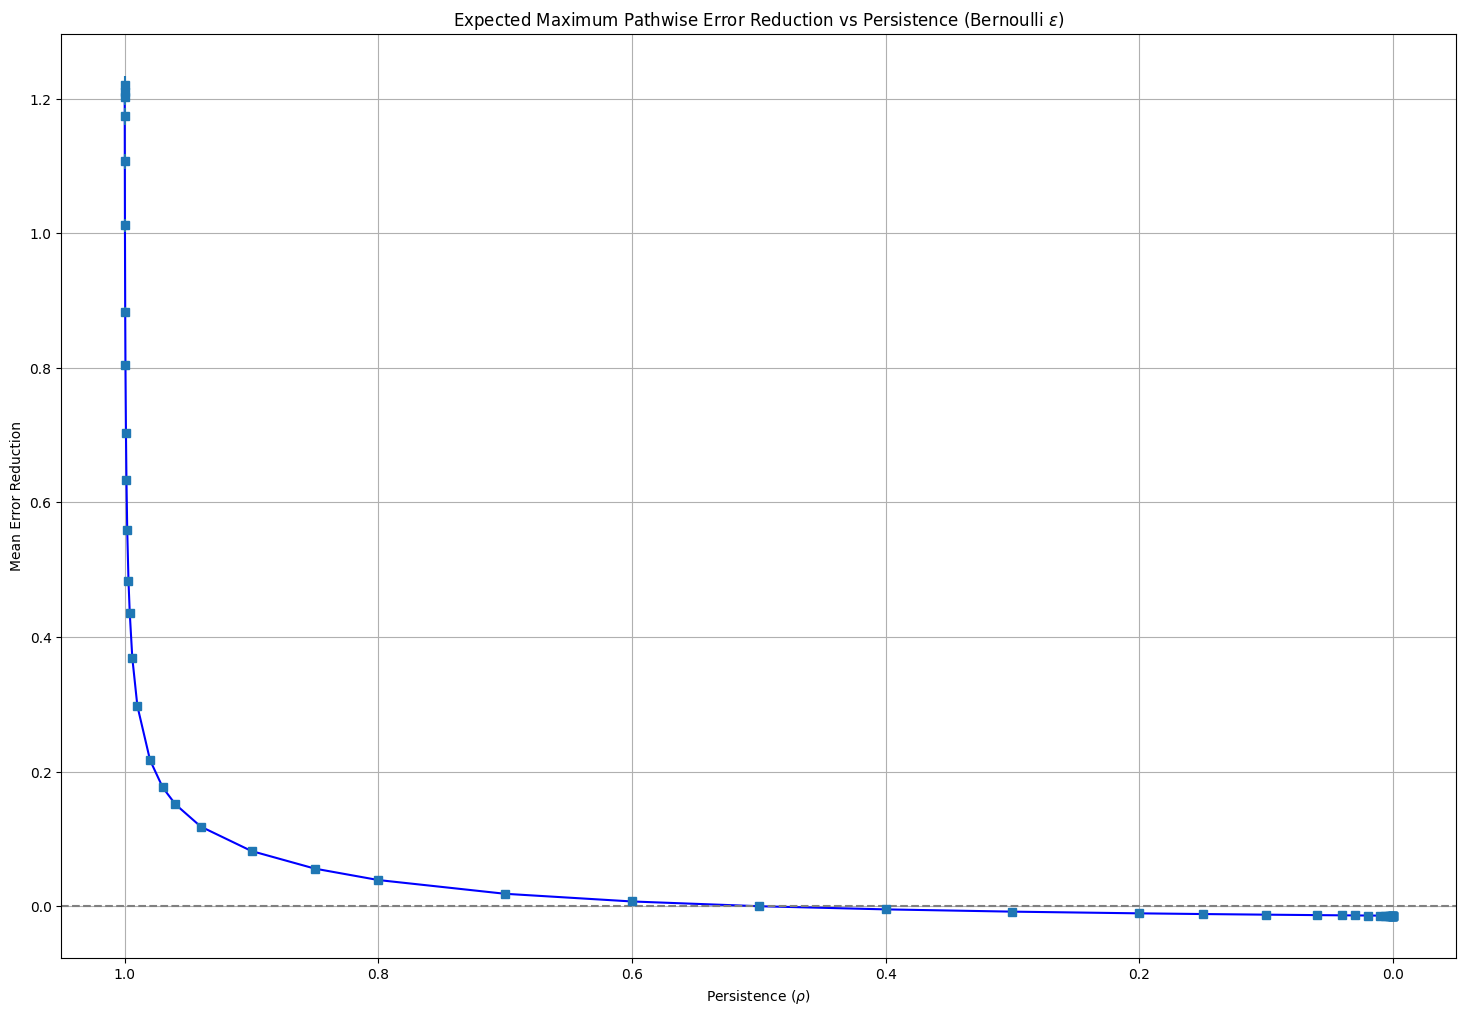

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------
# Parameters
# ---------------------------------

data = [
    [0.999998, 0.01, 1.219845, 0.006991, 98.671, 0.007, 1.206318, 1.233925],
    [0.999990, 0.05, 1.209026, 0.007017, 98.652, 0.008, 1.195657, 1.222678],
    [0.999980, 0.10, 1.202934, 0.006934, 98.647, 0.007, 1.189832, 1.216287],
    [0.999960, 0.20, 1.173605, 0.006574, 98.623, 0.007, 1.160771, 1.186431],
    [0.999900, 0.50, 1.106623, 0.005817, 98.559, 0.007, 1.094888, 1.117514],
    [0.999800, 1.00, 1.011523, 0.004872, 98.452, 0.007, 1.001860, 1.020888],
    [0.999600, 2.00, 0.883533, 0.003723, 98.261, 0.007, 0.876368, 0.890822],
    [0.999400, 3.00, 0.804786, 0.003074, 98.106, 0.007, 0.798808, 0.810624],
    [0.999000, 5.00, 0.702932, 0.002342, 97.842, 0.007, 0.698474, 0.707437],
    [0.998600, 7.00, 0.633239, 0.001942, 97.602, 0.007, 0.629313, 0.637116],
    [0.998000, 10.01, 0.559199, 0.001547, 97.276, 0.007, 0.556227, 0.562169],
    [0.997000, 15.02, 0.483102, 0.001226, 96.813, 0.007, 0.480650, 0.485444],
    [0.996000, 20.04, 0.435727, 0.001028, 96.431, 0.008, 0.433726, 0.437713],
    [0.994000, 30.09, 0.369074, 0.000787, 95.709, 0.008, 0.367503, 0.370632],
    [0.990000, 50.25, 0.297571, 0.000580, 94.503, 0.009, 0.296451, 0.298702],
    [0.980000, 101.01, 0.217024, 0.000367, 92.040, 0.011, 0.216310, 0.217752],
    [0.970000, 152.30, 0.176391, 0.000281, 89.861, 0.014, 0.175840, 0.176940],
    [0.960000, 204.11, 0.151384, 0.000227, 87.894, 0.016, 0.150936, 0.151834],
    [0.940000, 309.38, 0.118274, 0.000160, 84.099, 0.019, 0.117961, 0.118602],
    [0.900000, 526.80, 0.081984, 0.000095, 76.996, 0.022, 0.081796, 0.082173],
    [0.850000, 812.59, 0.055813, 0.000049, 68.092, 0.022, 0.055718, 0.055910],
    [0.800000, 1115.72, 0.038877, 0.000024, 58.916, 0.017, 0.038829, 0.038925],
    [0.700000, 1783.37, 0.018444, 0.000006, 39.734, 0.009, 0.018431, 0.018455],
    [0.600000, 2554.13, 0.007037, 0.000001, 19.962, 0.003, 0.007035, 0.007040],
    [0.500000, 3465.74, -0.000000, 0.000000, -0.001, 0.001, -0.000001, 0.000000],
    [0.400000, 4581.45, -0.004714, 0.000000, -19.999, 0.000, -0.004714, -0.004714],
    [0.300000, 6019.86, -0.008081, 0.000000, -40.000, 0.000, -0.008081, -0.008081],
    [0.200000, 8047.19, -0.010607, 0.000000, -60.000, 0.000, -0.010607, -0.010607],
    [0.150000, 9485.60, -0.011646, 0.000000, -70.000, 0.000, -0.011646, -0.011646],
    [0.100000, 11512.93, -0.012571, 0.000000, -80.000, 0.000, -0.012571, -0.012571],
    [0.060000, 14067.05, -0.013239, 0.000000, -88.000, 0.000, -0.013239, -0.013239],
    [0.040000, 16094.38, -0.013553, 0.000000, -92.000, 0.000, -0.013553, -0.013553],
    [0.030000, 17532.79, -0.013705, 0.000000, -94.000, 0.000, -0.013705, -0.013705],
    [0.020000, 19560.12, -0.013854, 0.000000, -96.000, 0.000, -0.013854, -0.013854],
    [0.010000, 23025.85, -0.013999, 0.000000, -98.000, 0.000, -0.013999, -0.013999],
    [0.006000, 25579.98, -0.014057, 0.000000, -98.800, 0.000, -0.014057, -0.014057],
    [0.004000, 27607.30, -0.014085, 0.000000, -99.200, 0.000, -0.014085, -0.014085],
    [0.003000, 29045.71, -0.014100, 0.000000, -99.400, 0.000, -0.014100, -0.014100],
    [0.002000, 31073.04, -0.014114, 0.000000, -99.600, 0.000, -0.014114, -0.014114],
    [0.001400, 32856.42, -0.014122, 0.000000, -99.720, 0.000, -0.014122, -0.014122],
    [0.001000, 34538.78, -0.014128, 0.000000, -99.800, 0.000, -0.014128, -0.014128],
    [0.000600, 37092.90, -0.014134, 0.000000, -99.880, 0.000, -0.014134, -0.014134],
    [0.000400, 39120.23, -0.014136, 0.000000, -99.920, 0.000, -0.014136, -0.014136],
    [0.000200, 42585.97, -0.014139, 0.000000, -99.960, 0.000, -0.014139, -0.014139],
    [0.000100, 46051.70, -0.014141, 0.000000, -99.980, 0.000, -0.014141, -0.014141],
    [0.000040, 50633.16, -0.014142, 0.000000, -99.992, 0.000, -0.014142, -0.014142],
    [0.000020, 54098.89, -0.014142, 0.000000, -99.996, 0.000, -0.014142, -0.014142],
    [0.000010, 57564.63, -0.014142, 0.000000, -99.998, 0.000, -0.014142, -0.014142],
    [0.000002, 65611.82, -0.014142, 0.000000, -100.000, 0.000, -0.014142, -0.014142],
]

arr = np.array(data)

rho = arr[:,0]
mean_D = arr[:,2]
se_D = arr[:,3]
ci_low = arr[:,6]
ci_high = arr[:,7]

yerr = np.vstack([
    mean_D - ci_low,
    ci_high - mean_D
])

# ---------------------------------
# Plot
# ---------------------------------

plt.figure(figsize=(18, 12))
plt.plot(rho, mean_D, color ='blue')
plt.axhline(0, linestyle='--', color='gray', linewidth=1.5)
plt.xlabel(r'Persistence $(\rho)$')
plt.ylabel('Mean Error Reduction')
plt.title('Expected Maximum Pathwise Error Reduction vs Persistence (Bernoulli $\u03B5$)')
plt.errorbar(rho, mean_D, yerr=yerr, fmt='s')
plt.gca().invert_xaxis()
plt.grid(True)